In [8]:
import tensorflow as tf
from tensorflow .keras. applications import MobileNetV2
from tensorflow .keras.layers import Dense ,GlobalAveragePooling2D
from tensorflow .keras.models import Model
import matplotlib.pyplot as plt

In [4]:
import tensorflow as tf
import pathlib

dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
data_dir = tf.keras.utils.get_file ('flower_photos', origin=dataset_url , untar=True)
data_dir = pathlib.Path(data_dir )
if (data_dir / 'flower_photos').exists ():
    data_dir = data_dir / 'flower_photos'
    print("Siniflar:", [item.name for item in data_dir.glob("*") if item.is_dir ()])

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 51s 0us/step 
Siniflar: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [5]:
batch_size = 32
img_size = (160 , 160)
train_ds = tf.keras. preprocessing . image_dataset_from_directory (
    data_dir ,
    validation_split =0.2 ,
    subset="training", seed =123 ,
    image_size =img_size ,
    batch_size = batch_size )
val_ds = tf.keras. preprocessing . image_dataset_from_directory (
    data_dir ,
    validation_split =0.2 ,
    subset="validation", seed =123 ,
    image_size =img_size ,
    batch_size = batch_size )

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


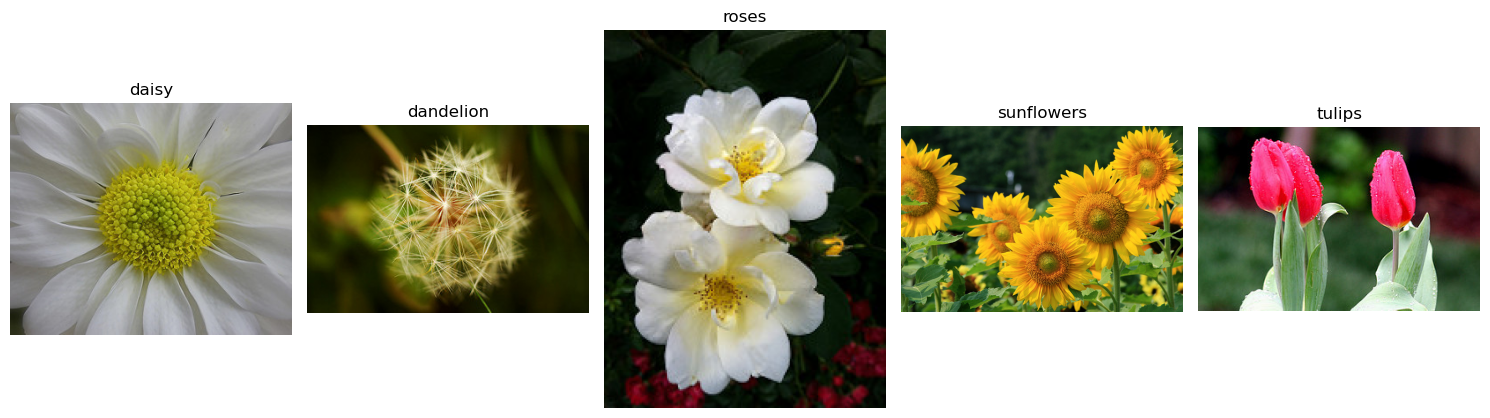

In [9]:
class_names = sorted([ item.name for item in data_dir.glob("*")
    if item.is_dir ()])
plt.figure(figsize =(15 , 5))

for i, class_name in enumerate( class_names ):
    image_path = list(( data_dir / class_name ).glob("*.jpg"))[0]
    img = plt.imread( image_path )
    plt.subplot (1, len( class_names ), i + 1)
    plt.imshow(img)
    plt.title( class_name )
    plt.axis("off")
plt.tight_layout ()
plt.show ()

In [16]:
base_model = MobileNetV2 ( input_shape =(160 , 160, 3),include_top =False ,weights='imagenet')

base_model . trainable = False
x = base_model .output
x = GlobalAveragePooling2D ()(x)
x = Dense (128 , activation ='relu')(x)
predictions = Dense (5, activation ='softmax')(x)
model = Model(inputs= base_model .input , outputs= predictions )

In [ ]:
model.compile( optimizer ='adam',
                loss='sparse_categorical_crossentropy',
                metrics =['accuracy'])
history_fe = model.fit(train_ds ,
                       validation_data =val_ds ,
                       epochs =5)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 504ms/step - accuracy: 0.5347 - loss: 1.2111 - val_accuracy: 0.6158 - val_loss: 1.0403
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6572 - loss: 0.8978 

In [ ]:
base_model.trainable = True
fine_tune_at = 100
for layer in base_model .layers [: fine_tune_at ]:
    layer. trainable = False
model.compile( optimizer =tf.keras. optimizers.Adam(1e-5) ,
                loss='sparse_categorical_crossentropy',
                metrics =['accuracy'])
history_ft = model.fit(train_ds ,
                       validation_data =val_ds ,
                       epochs =5)

In [ ]:
model.save('mobilenetv2_transfer.h5')
loss , acc = model.evaluate(val_ds)
print(f"Dogruluk orani: {acc:.2f}")